<a href="https://colab.research.google.com/github/Adossi-design/Malaria-Diagnosis/blob/main/Nehemie_AdvancedCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Problem Framing and Literature Review

**Why malaria diagnosis needs AI**

Malaria is one of the most dangerous diseases in the world. The World Health Organization reported over 249 million cases and more than 600,000 deaths in 2022, with most deaths happening in children under five years old in Africa (WHO, 2023). The standard way to diagnose malaria is to look at a blood smear slide under a microscope. A trained technician checks for the Plasmodium parasite inside red blood cells. This method is accurate when done well, but it is very slow, tiring, and expensive. In many rural areas of Africa, there are not enough trained technicians, so patients wait a long time for a diagnosis. Automating this process with deep learning could save lives by making diagnosis faster and cheaper.

**Convolutional Neural Networks for image classification**

LeCun et al. (1998) showed that Convolutional Neural Networks can learn visual features directly from raw pixel values using gradient-based training. This was a major advance because it removed the need for hand-crafted feature engineering. Since then, CNNs have become the standard approach for image classification. Simonyan and Zisserman (2014) introduced VGG16 and showed that using many small 3x3 filters in a deep network gives better results than using fewer large filters. VGG16 achieved state-of-the-art performance on ImageNet and became very popular for transfer learning. He et al. (2016) introduced ResNet, which uses skip connections to let gradients pass directly through layers without disappearing. This solved the vanishing gradient problem and allowed networks of 50 or more layers to train well. Sandler et al. (2018) introduced MobileNetV2, which uses depthwise separable convolutions and inverted residual blocks to achieve competitive accuracy with far fewer parameters. MobileNetV2 is especially useful in resource-limited settings like hospitals in rural Africa where computing power is limited.

**Transfer learning in medical imaging**

Pan and Yang (2010) defined transfer learning as using knowledge from one domain to help learning in a different domain. In medical imaging, this is very useful because medical datasets are usually small and expensive to label. Tajbakhsh et al. (2016) showed that fine-tuning pretrained CNNs on medical images gives much better results than training from scratch, especially when the dataset has fewer than 50,000 images. Our dataset from the NIH (National Institutes of Health) has about 27,000 cell images, which is a situation where transfer learning is strongly recommended.

**Malaria detection with CNNs**

Rajaraman et al. (2018) directly tested several pretrained CNNs on the NIH malaria cell dataset. They found that VGG16 achieved over 95% accuracy on parasitized vs. uninfected cell classification. Their work directly motivates our choice of VGG16, ResNet50, and MobileNetV2 in this project. They also showed that fine-tuning beats pure feature extraction for this task, which is why we run experiments with progressive layer unfreezing.

**Regularization techniques**

Srivastava et al. (2014) introduced dropout, which randomly sets a fraction of activations to zero during training. This stops neurons from relying too much on each other and reduces overfitting. Ioffe and Szegedy (2015) introduced Batch Normalization, which normalizes activations within each mini-batch during training. This reduces internal covariate shift, speeds up convergence, and also acts as a regularizer. These two techniques are used in our baseline and advanced CNN experiments.

**Connection to this project**

Each model in our group is grounded in the literature above. Adossi's baseline CNN follows the standard Conv-Pool-Dense structure from LeCun et al. (1998). Nehemie's advanced CNN adds Batch Normalization from Ioffe and Szegedy (2015) and Dropout from Srivastava et al. (2014). Berissa uses VGG16 from Simonyan and Zisserman (2014) with the fine-tuning strategy recommended by Rajaraman et al. (2018). Elvin uses ResNet50 from He et al. (2016) with frozen BatchNormalization layers following best practices for ResNet fine-tuning. Gabriel uses MobileNetV2 from Sandler et al. (2018), which is the most practical model for real-world deployment in low-resource clinical settings.

**References**

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*, 770-778.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*, 448-456.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.
- Pan, S. J., & Yang, Q. (2010). A survey on transfer learning. *IEEE Transactions on Knowledge and Data Engineering*, 22(10), 1345-1359.
- Rajaraman, S., Antani, S. K., Poostchi, M., Silamut, K., Hossain, M. A., Maude, R. J., & Jaeger, S. (2018). Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images. *PeerJ*, 6, e4568.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR*, 4510-4520.
- Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. *ICLR*.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Drozdov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15(1), 1929-1958.
- Tajbakhsh, N., et al. (2016). Convolutional neural networks for medical image analysis: Full training or fine tuning? *IEEE Transactions on Medical Imaging*, 35(5), 1299-1312.
- WHO. (2023). *World Malaria Report 2023*. World Health Organization.

## Configuration

In [ ]:

from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(tf.__version__)
tf.test.gpu_device_name()


2.20.0


'/device:GPU:0'

## Imports

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Load  DataSet

In [ ]:
# Download the data in the allocated google cloud-server.
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else:
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-08 15:36:24--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 65.9.168.69, 65.9.168.87, 65.9.168.66, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|65.9.168.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   190MB/s    in 1.8s    

2026-06-08 15:36:26 (190 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


### other Imports

In [ ]:
import warnings
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED       = 42
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
CLASSES    = ['Parasitized', 'Uninfected']
EPOCHS_MAX = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Additional libraries loaded.')

Additional libraries loaded.


### Split DataSet

In [ ]:
def create_splits(rebuild=False):
    if os.path.exists(training_path) and not rebuild:
        print('Folders already exist. Set rebuild=True to redo.')
        for sp in ['train', 'test']:
            for cls in CLASSES:
                print(f'  {sp}/{cls}: {len(os.listdir(os.path.join(sp, cls))):,}')
        return
    for sp in ['train', 'test']:
        if os.path.exists(sp): shutil.rmtree(sp)
    for sp in ['train', 'test']:
        for cls in CLASSES:
            os.makedirs(os.path.join(sp, cls), exist_ok=True)
    for cls in CLASSES:
        src   = os.path.join(cell_images_dir, cls)
        files = [f for f in os.listdir(src) if f.endswith('.png')]
        random.shuffle(files)
        n = len(files); n_tr = int(n * 0.80)
        for sp, fl in [('train', files[:n_tr]), ('test', files[n_tr:])]:
            for f in fl:
                shutil.copy(os.path.join(src, f), os.path.join(sp, cls, f))
            print(f'  {sp}/{cls}: {len(fl):,}')
    print('Split complete.')

create_splits(rebuild=False)

  train/Parasitized: 11,023
  test/Parasitized: 2,756
  train/Uninfected: 11,023
  test/Uninfected: 2,756
Split complete.


### Data processing

In [ ]:
def make_generators(batch_size=64, aug=False, preprocess_fn=None):
    if preprocess_fn is not None:
        aug_cfg   = dict(preprocessing_function=preprocess_fn, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(preprocessing_function=preprocess_fn)
        te_cfg    = dict(preprocessing_function=preprocess_fn)
    else:
        aug_cfg   = dict(rescale=1./255, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(rescale=1./255)
        te_cfg    = dict(rescale=1./255)
    kw = dict(target_size=IMG_SIZE, batch_size=batch_size, class_mode='binary')
    tr = ImageDataGenerator(**(aug_cfg if aug else plain_cfg))
    te = ImageDataGenerator(**te_cfg)
    tg = tr.flow_from_directory(training_path, seed=SEED, **kw)
    eg = te.flow_from_directory(testing_path, shuffle=False, **kw)
    return tg, eg

train_gen, test_gen = make_generators()
print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.n:,} | Test: {test_gen.n:,}')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Train: 22,046 | Test: 5,512


### picture of Sample

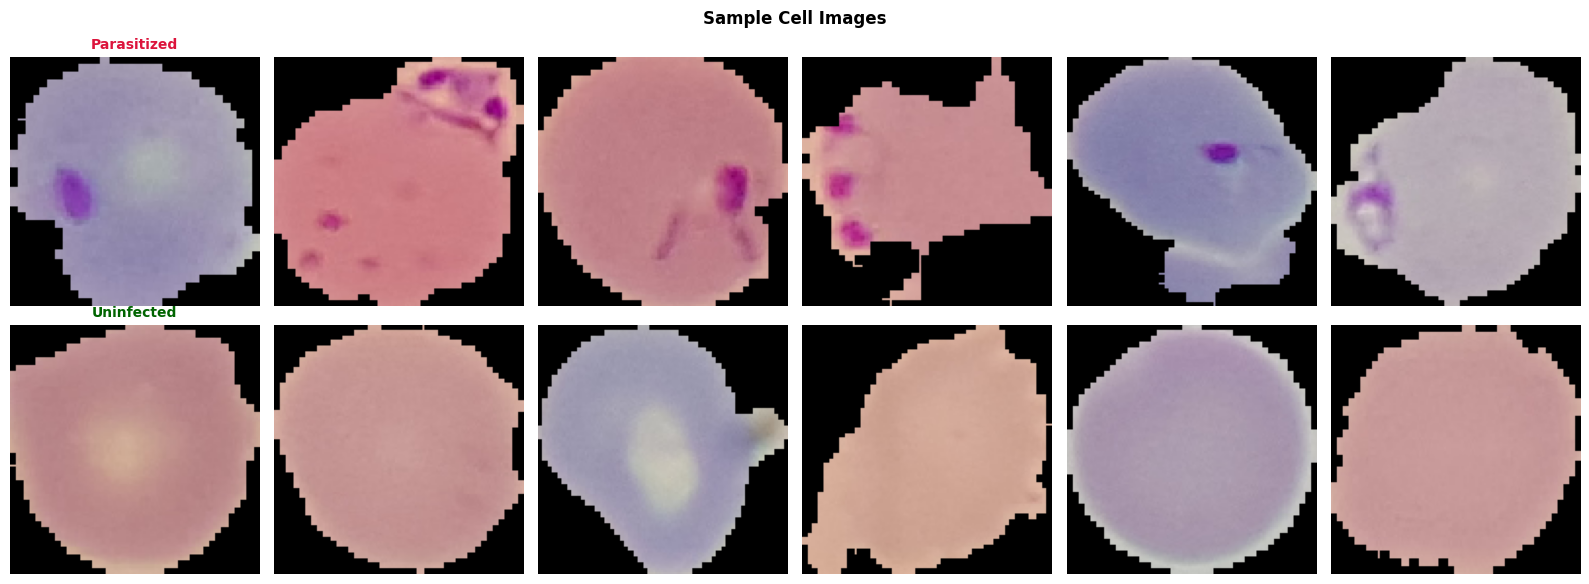

In [ ]:
cls_names = list(train_gen.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Cell Images', fontsize=12, fontweight='bold')
imgs, lbls = next(train_gen)
shown = {0:0, 1:0}
for img, lbl in zip(imgs, lbls):
    lbl = int(lbl); col = shown[lbl]
    if col < 6:
        axes[lbl, col].imshow(img); axes[lbl, col].axis('off')
        if col == 0:
            axes[lbl, col].set_title(cls_names[lbl], fontsize=10,
                color='crimson' if lbl==0 else 'darkgreen', fontweight='bold')
        shown[lbl] += 1
    if shown[0]==6 and shown[1]==6: break
pyplot.tight_layout(); pyplot.show()

### Performance Evaluation

In [ ]:
def plot_learning_curves(history, name='Model'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    ep = range(1, len(acc)+1)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} -- Learning Curves', fontsize=13, fontweight='bold')
    a1.plot(ep, acc, 'b-o', ms=3, label='Train')
    a1.plot(ep, val_acc, 'r-o', ms=3, label='Test')
    a1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, loss, 'b-o', ms=3, label='Train')
    a2.plot(ep, val_loss, 'r-o', ms=3, label='Test')
    a2.set(title='Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy')
    a2.legend(); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_curves.png', dpi=150, bbox_inches='tight')
    pyplot.show()


def evaluate_model(model, gen, name='Model', threshold=0.5):
    gen.reset()
    probs  = model.predict(gen, verbose=0).flatten()
    yp     = (probs >= threshold).astype(int)
    yt     = gen.classes
    cnames = list(gen.class_indices.keys())
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fpr, tpr, _ = roc_curve(yt, 1-probs, pos_label=0)
    roc_auc = auc(fpr, tpr)
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC       : {roc_auc:.4f}')
    print(f'{"="*50}')
    print(classification_report(yt, yp, target_names=cnames))
    cm = confusion_matrix(yt, yp)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a1,
                xticklabels=cnames, yticklabels=cnames)
    a1.set(title=f'{name} -- Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    tn, fp, fn, tp = cm.ravel()
    a1.text(0.5, -0.13, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
            transform=a1.transAxes, ha='center', fontsize=9, color='navy')
    a2.plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    a2.fill_between(fpr, tpr, alpha=0.07, color='darkorange')
    a2.plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random (AUC=0.5)')
    a2.set(xlim=[0,1], ylim=[0,1.02], title=f'{name} -- ROC/AUC',
           xlabel='False Positive Rate', ylabel='True Positive Rate')
    a2.legend(loc='lower right'); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_eval.png', dpi=150, bbox_inches='tight')
    pyplot.show()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)


def results_table(experiments):
    hdr = (f"{'Exp':>4} | {'Description':<35} | "
           f"{'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'AUC':>6}")
    sep = '='*len(hdr)
    print(f'\n{sep}\n{hdr}\n{sep}')
    for e in experiments:
        print(f"{e['id']:>4} | {e['desc']:<35} | {e['accuracy']:.4f} | "
              f"{e['precision']:.4f} | {e['recall']:.4f} | "
              f"{e['f1']:.4f} | {e['auc']:.4f}")
    print(sep)


def get_callbacks(name):
    os.makedirs('saved_models', exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'saved_models/{name}.keras',
                                  monitor='val_accuracy', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [ ]:
import os

SAVE_DIR = '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

def train_or_load(name, model, tg, eg):
    path = os.path.join(SAVE_DIR, name + '.keras')
    if os.path.exists(path):
        print(f'  Skipping {name} -- loading saved weights from {path}')
        model = tf.keras.models.load_model(path)
        return model, None
    history = model.fit(
        tg, epochs=EPOCHS_MAX, validation_data=eg,
        callbacks=get_callbacks(name), verbose=1
    )
    model.save(path)
    print(f'  Saved {name} -> {path}')
    return model, history

---
## Advanced CNN Model

**Nehemie Ishimwe**

**What makes this model different**

My model builds on the baseline by adding BatchNormalization after each conv layer to keep the activations in a stable range which helps training go a lot faster and more smoothly. I also made the number of blocks adjustable between three and four so I could test whether going deeper actually helps and I added the option to swap Flatten for GlobalAveragePooling which cuts the head size way down and reduces the risk of overfitting in the classifier. On top of that I put two Dropout layers in the head for extra regularization and I also tested SGD with Nesterov momentum to see how it compares against Adam.

| Exp | Variable | Hypothesis |
|-----|----------|------------|
| 1 | Default: 3 blocks + BN + Dropout(0.3) + Adam | Should be better than baseline because of BN and depth |
| 2 | 4 conv blocks (32-64-128-256) | A deeper model can learn more complex features |
| 3 | Remove BN, keep Dropout(0.3) | Without BN the training should be less stable |
| 4 | L2 weight regularization (0.001) | Adding weight penalty should reduce overfitting further |
| 5 | GlobalAveragePooling instead of Flatten | Fewer parameters in the head should reduce overfitting |
| 6 | Combined: GAP + BN + Dropout + Augmentation | Using all good techniques together should give the best results |
| 7 | SGD with Nesterov momentum | Testing if SGD generalizes better than Adam |

In [ ]:
def build_advanced(lr=0.001, dropout=0.3, use_bn=True,
                   n_blocks=3, use_gap=False, l2_reg=0.0, opt_name='adam'):
    filters = [32, 64, 128, 256][:n_blocks]
    inp = Input(shape=(128, 128, 3))
    x   = inp
    for f in filters:
        reg = l2(l2_reg) if l2_reg > 0 else None
        x = Conv2D(f, (3,3), activation='relu', padding='same',
                   kernel_regularizer=reg)(x)
        if use_bn: x = BatchNormalization()(x)
        x = MaxPooling2D(2, 2)(x)
    x = GlobalAveragePooling2D()(x) if use_gap else Flatten()(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout * 0.5)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='Advanced_CNN')
    opt = (optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
           if opt_name=='sgd' else optimizers.Adam(learning_rate=lr))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_advanced().summary()

Model: "Advanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

##### exp1: Default 3-block, BatchNorm, Dropout(0.3), Adam

This is my starting point for the advanced CNN and it already has BatchNormalization and Dropout built in from the beginning so I expected it to perform clearly better than the baseline right away because of the added depth and regularization working together.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - accuracy: 0.4983 - loss: 8.0173 - val_accuracy: 0.4975 - val_loss: 8.0194 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.5000 - loss: 8.0590 - val_accuracy: 0.5000 - val_loss: 8.0591 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.5000 - loss: 8.0590 - val_accuracy: 0.5000 - val_loss: 8.0591 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4966 - loss: 8.1146
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
345/345 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.5000 - loss: 8.0590 - val_accuracy: 0.5000 - val_loss: 8.0591 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.5000 - loss: 8.0590 - val_accuracy: 0.5000 - val_loss: 8.0591 - learning_rat

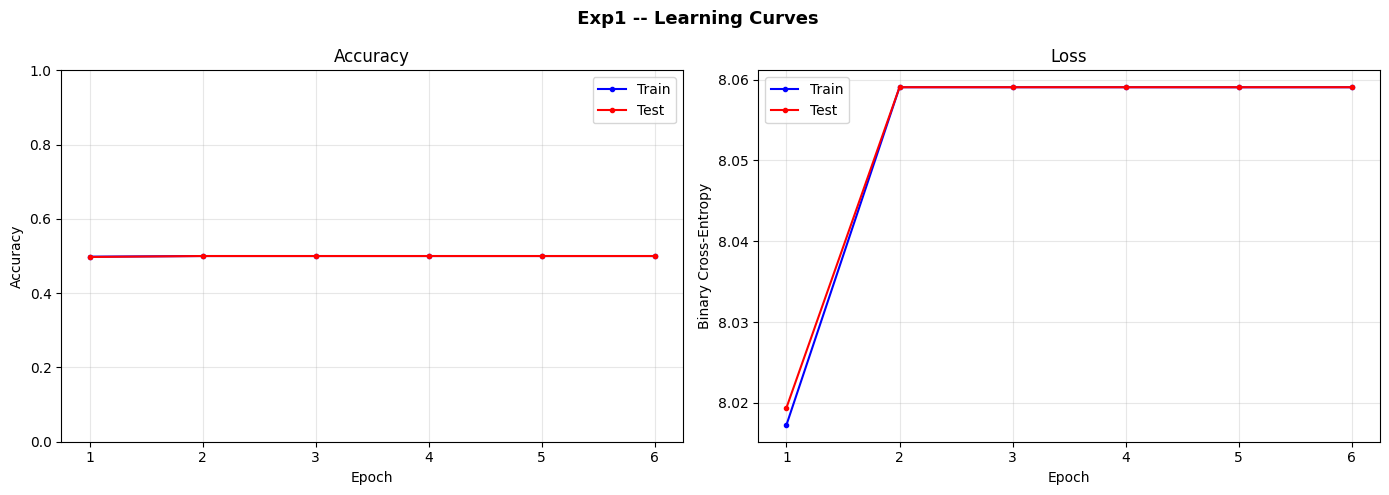


  Exp1
  Accuracy  : 0.4975
  Precision : 0.3600
  Recall    : 0.0065
  F1-Score  : 0.0128
  AUC       : 0.4971
              precision    recall  f1-score   support

 Parasitized       0.50      0.99      0.66      2756
  Uninfected       0.36      0.01      0.01      2756

    accuracy                           0.50      5512
   macro avg       0.43      0.50      0.34      5512
weighted avg       0.43      0.50      0.34      5512



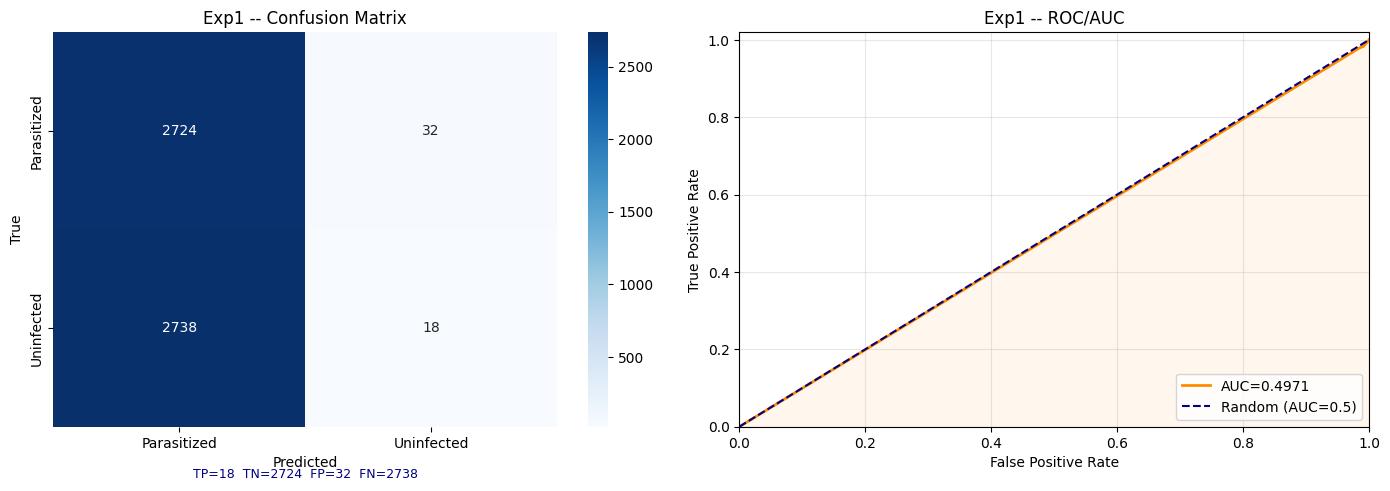

In [ ]:
tg, eg = make_generators()
n1 = build_advanced(0.001,0.3,True,3,False,0.0,'adam')
n1, hn1 = train_or_load('N_exp1', n1, tg, eg)
if hn1: plot_learning_curves(hn1, ' Exp1')
rn1 = evaluate_model(n1, eg, 'Exp1')

##### exp2: 4 convolutional blocks with BatchNorm

I added a fourth block with 256 filters to give the model more depth and I wanted to see if a deeper network could learn more complex patterns from the cell images even though adding more layers also means a higher chance of the training accuracy pulling away from validation.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 53s 123ms/step - accuracy: 0.5007 - loss: 7.8740 - val_accuracy: 0.5134 - val_loss: 7.3196 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.5000 - loss: 7.9712 - val_accuracy: 0.5002 - val_loss: 7.9683 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.5000 - loss: 7.9712 - val_accuracy: 0.5000 - val_loss: 7.9691 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5019 - loss: 7.9409
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
345/345 ━━━━━━━━━━━━━━━━━━━━ 36s 106ms/step - accuracy: 0.5000 - loss: 7.9712 - val_accuracy: 0.5000 - val_loss: 7.9691 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.5000 - loss: 7.9712 - val_accuracy: 0.5000 - val_loss: 7.9691 - learning_rate: 5.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.500

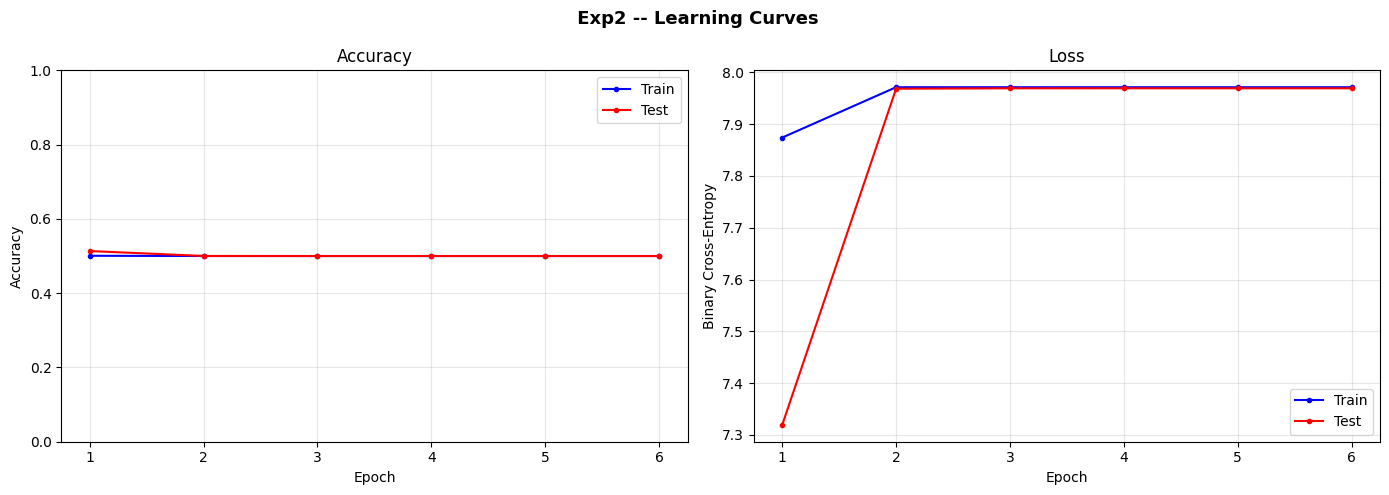


   Exp2
  Accuracy  : 0.5134
  Precision : 0.5070
  Recall    : 0.9779
  F1-Score  : 0.6677
  AUC       : 0.5261
              precision    recall  f1-score   support

 Parasitized       0.69      0.05      0.09      2756
  Uninfected       0.51      0.98      0.67      2756

    accuracy                           0.51      5512
   macro avg       0.60      0.51      0.38      5512
weighted avg       0.60      0.51      0.38      5512



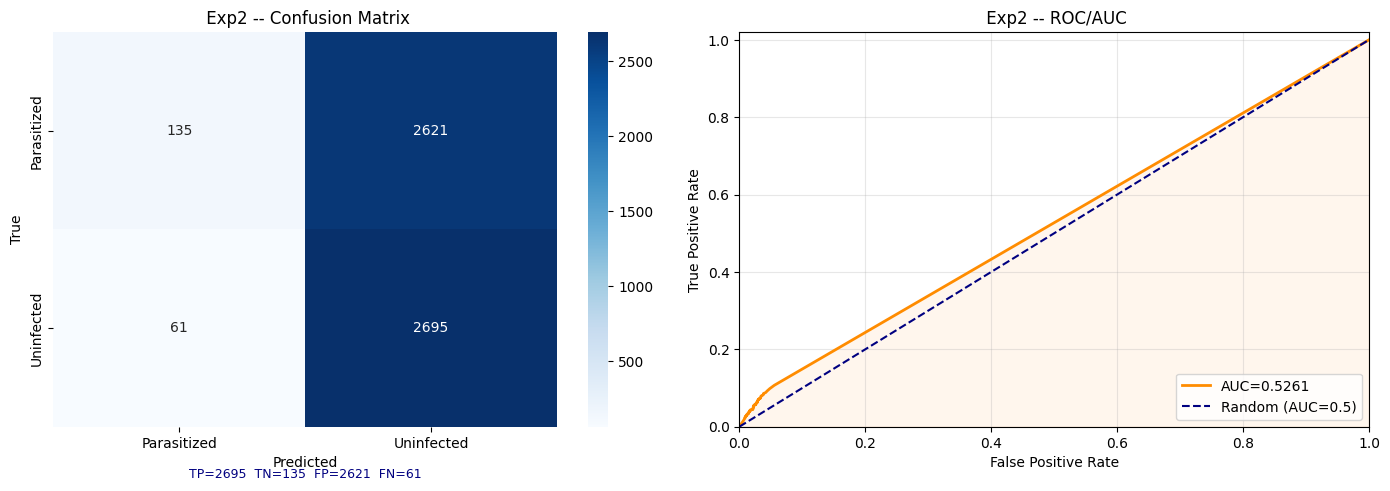

In [ ]:
n2 = build_advanced(0.001,0.3,True,4,False,0.0,'adam')
n2, hn2 = train_or_load('N_exp2', n2, tg, eg)
if hn2: plot_learning_curves(hn2, ' Exp2')
rn2 = evaluate_model(n2, eg, ' Exp2')

#### exp3: 3 blocks, NO BatchNorm, Dropout(0.3)

I took out BatchNormalization entirely here to see how much it actually contributes on its own and based on Ioffe and Szegedy (2015) removing it should make the training noisier and the loss curves less stable which would confirm that BN is doing real useful work.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.7494 - loss: 0.5835 - val_accuracy: 0.9374 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.9191 - loss: 0.3012 - val_accuracy: 0.9351 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9364 - loss: 0.2392 - val_accuracy: 0.9479 - val_loss: 0.2188 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.9528 - loss: 0.1574 - val_accuracy: 0.9561 - val_loss: 0.1447 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9592 - loss: 0.1244 - val_accuracy: 0.9545 - val_loss: 0.1474 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.9629 - loss: 0.1090 - val_accuracy: 0.9561 - val_loss: 0.1552 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9687 - l

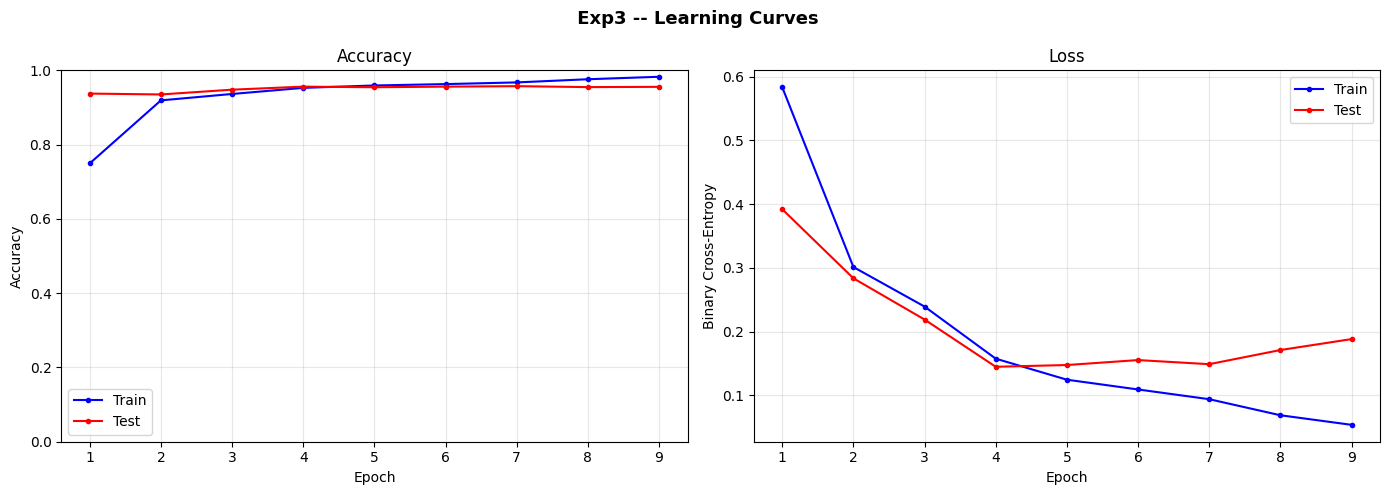


   Exp3
  Accuracy  : 0.9561
  Precision : 0.9401
  Recall    : 0.9742
  F1-Score  : 0.9569
  AUC       : 0.9871
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.96      2756
  Uninfected       0.94      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



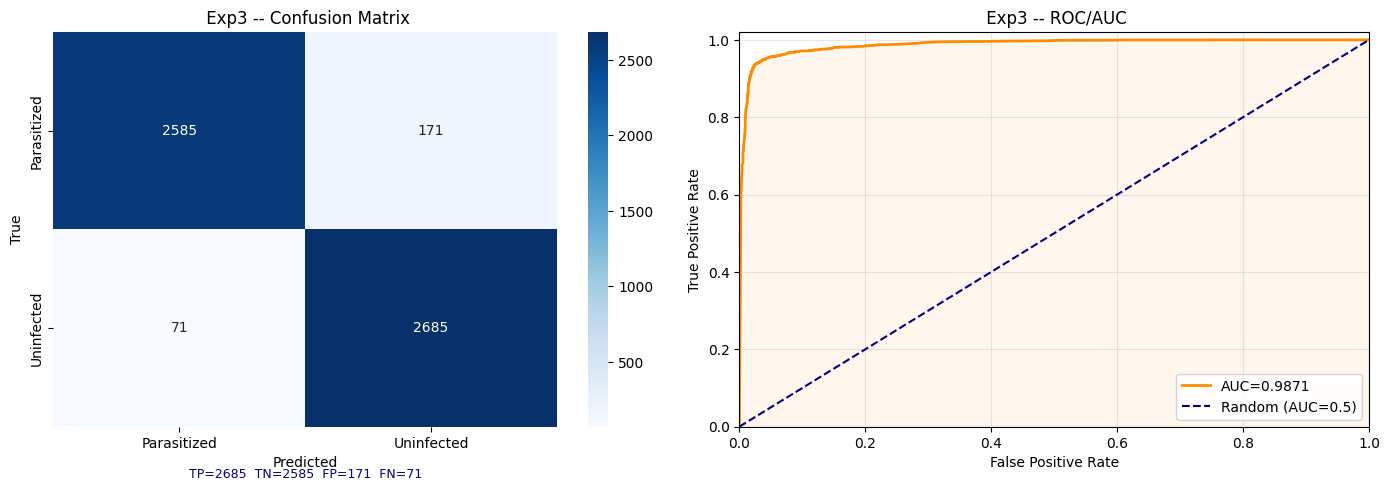

In [ ]:
n3 = build_advanced(0.001,0.3,False,3,False,0.0,'adam')
n3, hn3 = train_or_load('N_exp3', n3, tg, eg)
if hn3: plot_learning_curves(hn3, ' Exp3')
rn3 = evaluate_model(n3, eg, ' Exp3')

#### exp4: 3 blocks, BatchNorm, L2 regularization (0.001)

I added L2 weight regularization to the conv layers which penalizes large weights and keeps them small and combined with the dropout already in the head this gives the model both weight level and activation level regularization working at the same time.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.5455 - loss: 7.2782 - val_accuracy: 0.5062 - val_loss: 8.0036 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.6277 - loss: 6.0482 - val_accuracy: 0.5927 - val_loss: 6.6032 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.6784 - loss: 5.2141 - val_accuracy: 0.6252 - val_loss: 6.0851 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.7374 - loss: 4.2862 - val_accuracy: 0.8873 - val_loss: 1.9190 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.8900 - loss: 1.8449 - val_accuracy: 0.9220 - val_loss: 1.3594 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9150 - loss: 1.4219 - val_accuracy: 0.9318 - val_loss: 1.1123 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.9272 -

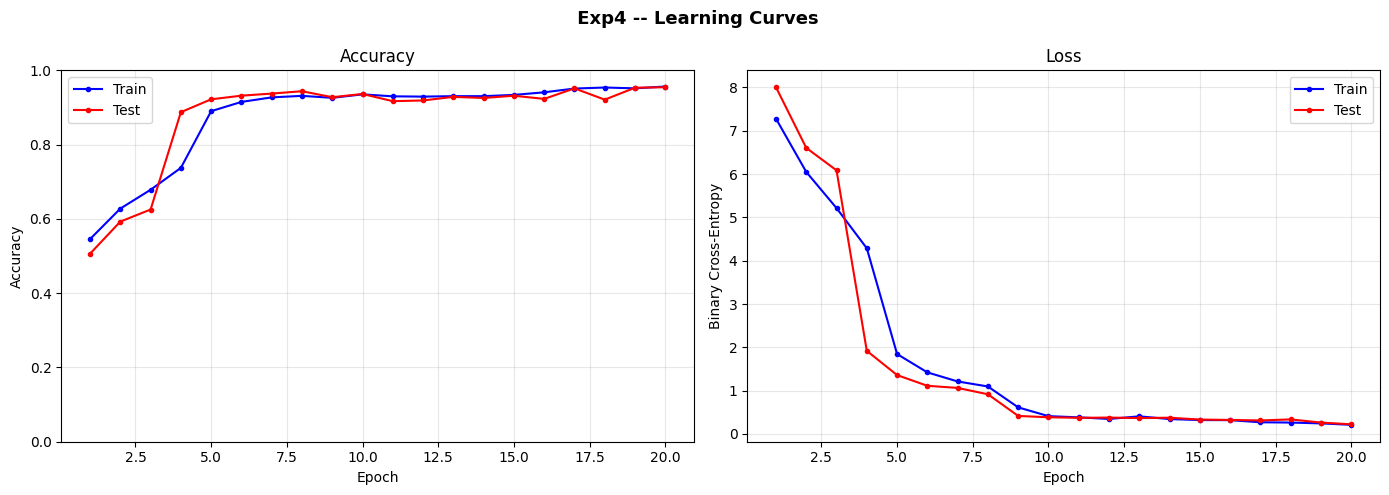


   Exp4
  Accuracy  : 0.9545
  Precision : 0.9402
  Recall    : 0.9706
  F1-Score  : 0.9552
  AUC       : 0.9847
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.95      2756
  Uninfected       0.94      0.97      0.96      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



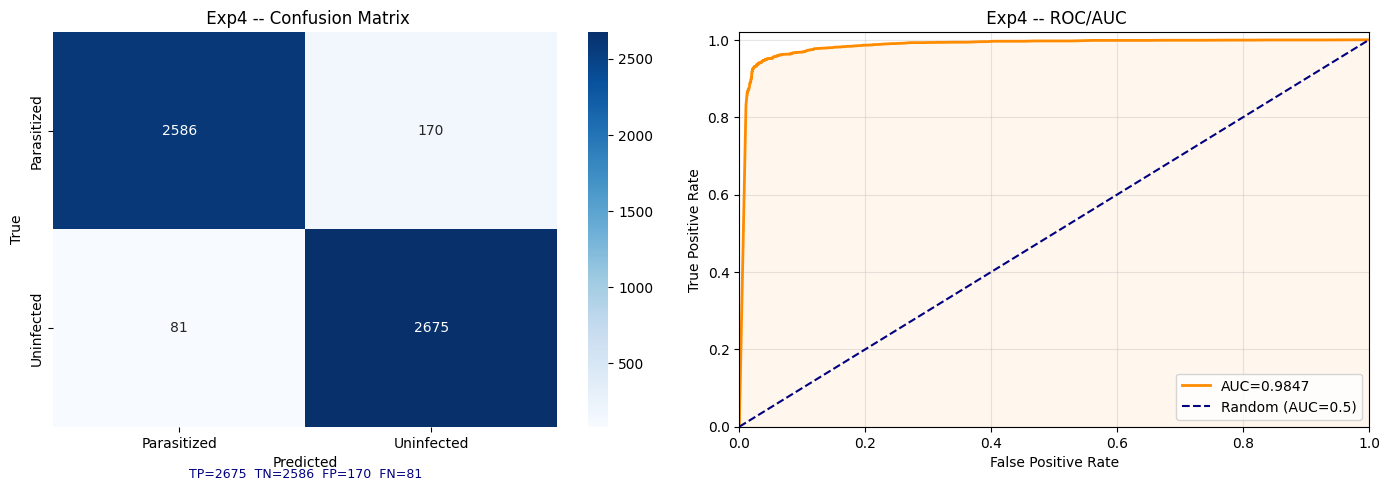

In [ ]:
n4 = build_advanced(0.001,0.3,True,3,False,0.001,'adam')
n4, hn4 = train_or_load('N_exp4', n4, tg, eg)
if hn4: plot_learning_curves(hn4, ' Exp4')
rn4 = evaluate_model(n4, eg, ' Exp4')

#### exp5: 3 blocks, BatchNorm, GlobalAveragePooling

I swapped Flatten for GlobalAveragePooling here and the difference in head size is quite big since Flatten gives around 32,000 values going into the Dense layer while GlobalAveragePooling gives only 128 which is a much smaller head that is far less likely to overfit the training data.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.8614 - loss: 0.3399 - val_accuracy: 0.5000 - val_loss: 2.8765 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9420 - loss: 0.1725 - val_accuracy: 0.9093 - val_loss: 0.2361 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9496 - loss: 0.1502 - val_accuracy: 0.5065 - val_loss: 1.2153 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - accuracy: 0.9512 - loss: 0.1425 - val_accuracy: 0.9445 - val_loss: 0.1825 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.9550 - loss: 0.1345 - val_accuracy: 0.9488 - val_loss: 0.1816 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9557 - loss: 0.1295 - val_accuracy: 0.9499 - val_loss: 0.1491 - learning_rate: 0.0010
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.9564 

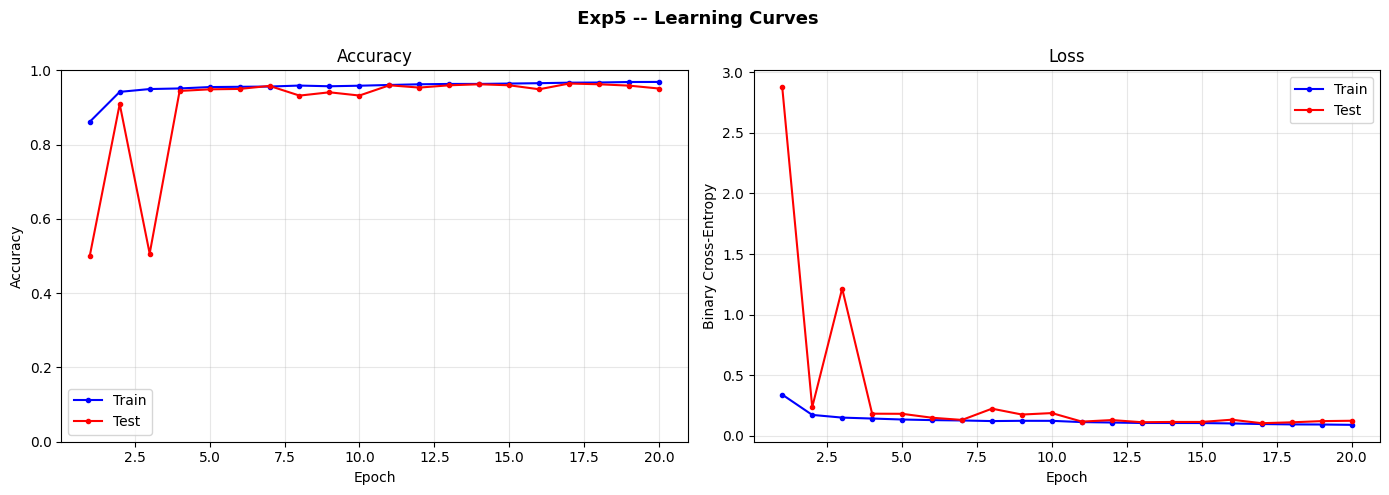


   Exp5
  Accuracy  : 0.9643
  Precision : 0.9529
  Recall    : 0.9768
  F1-Score  : 0.9647
  AUC       : 0.9927
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2756
  Uninfected       0.95      0.98      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



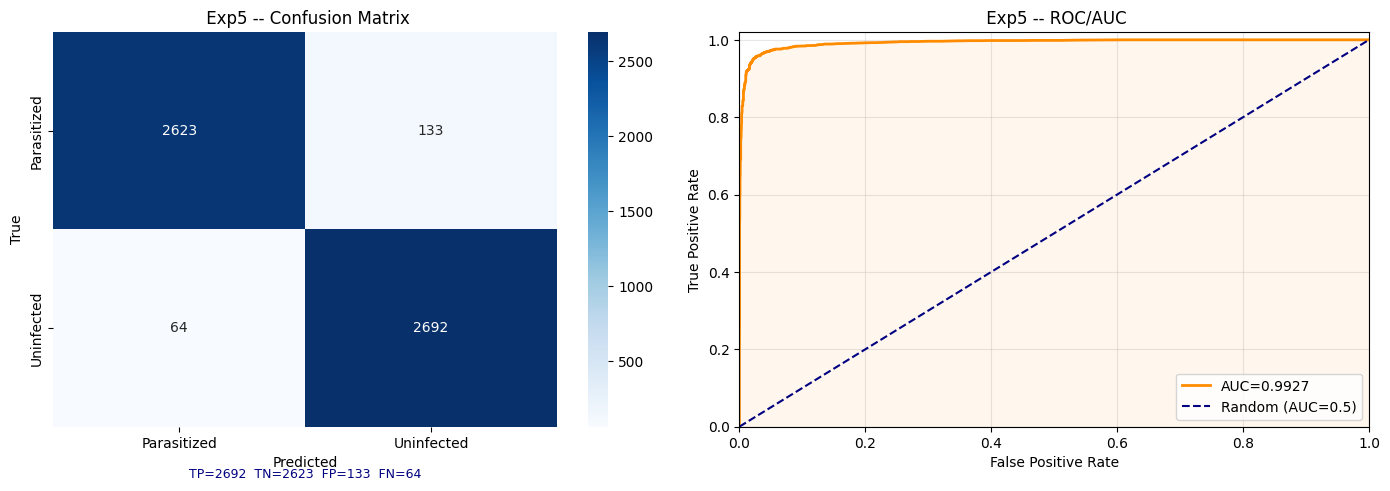

In [ ]:
n5 = build_advanced(0.001,0.3,True,3,True,0.0,'adam')
n5, hn5 = train_or_load('N_exp5', n5, tg, eg)
if hn5: plot_learning_curves(hn5, ' Exp5')
rn5 = evaluate_model(n5, eg, ' Exp5')

#### exp6: GAP ,BatchNorm , Dropout and Augmentation

This run stacks everything that worked well across the previous experiments including GlobalAveragePooling, BatchNormalization, Dropout and data augmentation all at the same time and I expected this combination to give the strongest results since every layer of regularization is active together.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 127s 344ms/step - accuracy: 0.8485 - loss: 0.3573 - val_accuracy: 0.5000 - val_loss: 2.5849 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 114s 329ms/step - accuracy: 0.9373 - loss: 0.1875 - val_accuracy: 0.9352 - val_loss: 0.2073 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 115s 333ms/step - accuracy: 0.9436 - loss: 0.1740 - val_accuracy: 0.9566 - val_loss: 0.1447 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 114s 331ms/step - accuracy: 0.9470 - loss: 0.1600 - val_accuracy: 0.9231 - val_loss: 0.2867 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 113s 328ms/step - accuracy: 0.9483 - loss: 0.1582 - val_accuracy: 0.9556 - val_loss: 0.1637 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9516 - loss: 0.1502
Epoch 6: ReduceLROnPlateau reducing learning ra

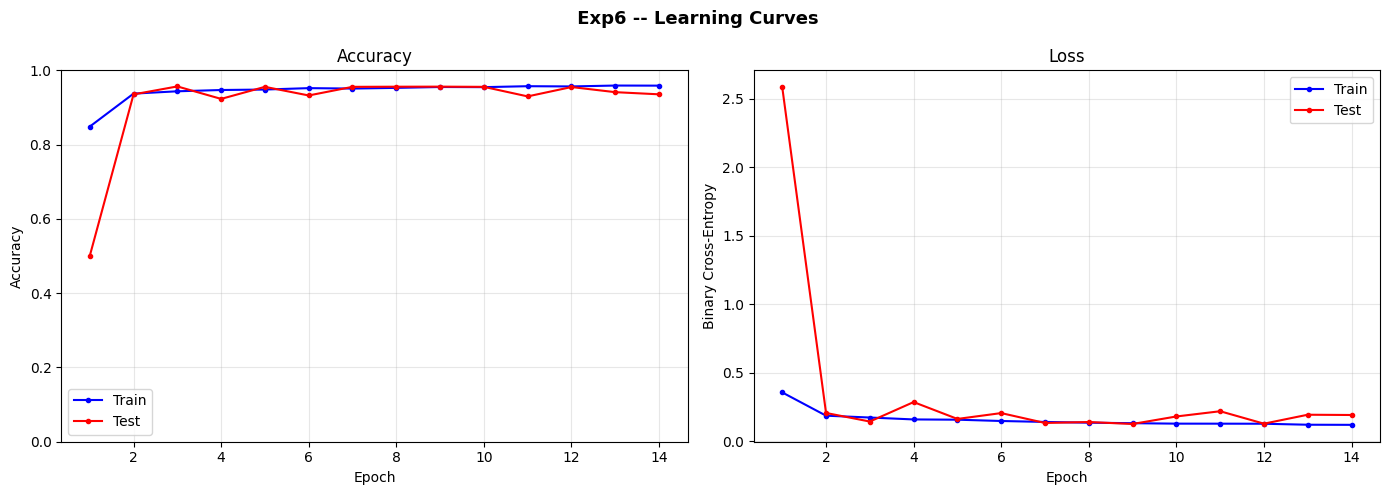


   Exp6
  Accuracy  : 0.9561
  Precision : 0.9389
  Recall    : 0.9757
  F1-Score  : 0.9569
  AUC       : 0.9901
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.96      2756
  Uninfected       0.94      0.98      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



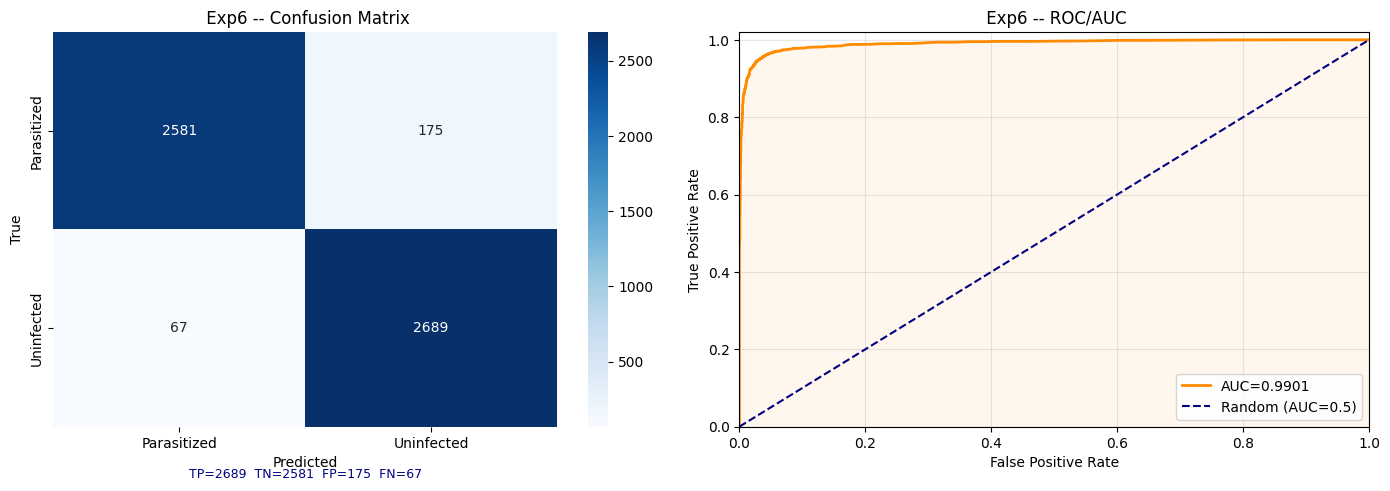

In [ ]:
tg_aug, eg = make_generators(aug=True)
n6 = build_advanced(0.001,0.3,True,3,True,0.0,'adam')
n6, hn6 = train_or_load('N_exp6', n6, tg_aug, eg)
if hn6: plot_learning_curves(hn6, ' Exp6')
rn6 = evaluate_model(n6, eg, ' Exp6')

#### exp7: 3 blocks, BatchNorm, SGD with Nesterov momentum

I swapped Adam for SGD with Nesterov momentum to see if a different optimizer changes the outcome and while some research suggests SGD generalizes better on vision tasks the trade off is that it usually needs more epochs to converge so within 20 epochs the model may not have had enough time to fully train.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.7434 - loss: 0.5706 - val_accuracy: 0.5354 - val_loss: 1.8307 - learning_rate: 0.0010
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9267 - loss: 0.1995 - val_accuracy: 0.9262 - val_loss: 0.2177 - learning_rate: 0.0010
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9442 - loss: 0.1610 - val_accuracy: 0.9224 - val_loss: 0.1969 - learning_rate: 0.0010
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9504 - loss: 0.1411 - val_accuracy: 0.9448 - val_loss: 0.1619 - learning_rate: 0.0010
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9564 - loss: 0.1281 - val_accuracy: 0.9334 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.9589 - loss: 0.1175 - val_accuracy: 0.9536 - val_loss: 0.1474 - learning_rat

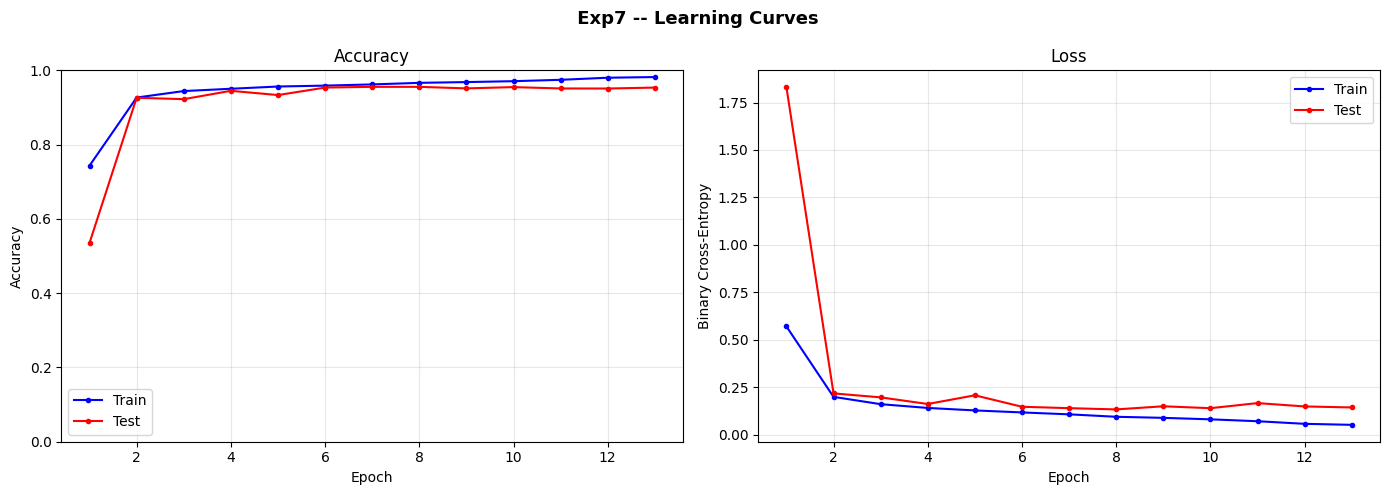


   Exp7
  Accuracy  : 0.9556
  Precision : 0.9413
  Recall    : 0.9717
  F1-Score  : 0.9563
  AUC       : 0.9889
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.95      2756
  Uninfected       0.94      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



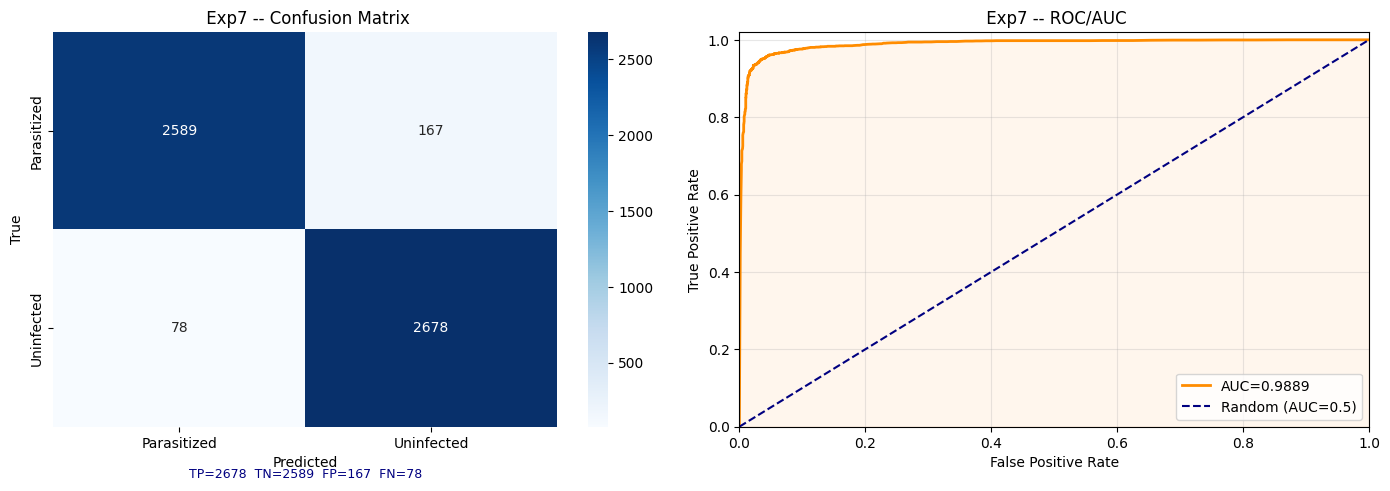

In [ ]:
tg, eg = make_generators()
n7 = build_advanced(0.001,0.3,True,3,False,0.0,'sgd')
n7, hn7 = train_or_load('N_exp7', n7, tg, eg)
if hn7: plot_learning_curves(hn7, ' Exp7')
rn7 = evaluate_model(n7, eg, ' Exp7')

#### Experiment Results

In [ ]:
nehemie_res = [
    {'id':1,'desc':'3-block BN Dropout Adam',**rn1},
    {'id':2,'desc':'4 blocks 32-64-128-256',**rn2},
    {'id':3,'desc':'3 blocks NO BN',**rn3},
    {'id':4,'desc':'3 blocks BN + L2',**rn4},
    {'id':5,'desc':'3 blocks BN + GAP',**rn5},
    {'id':6,'desc':'GAP+BN+Dropout+Aug',**rn6},
    {'id':7,'desc':'3 blocks BN + SGD',**rn7},
]
results_table(nehemie_res)
best_n = max(nehemie_res, key=lambda x: x['f1'])
print(f'Best: Exp {best_n["id"]} | F1={best_n["f1"]:.4f} | AUC={best_n["auc"]:.4f}')


 Exp | Description                         |    Acc |   Prec |    Rec |     F1 |    AUC
   1 | 3-block BN Dropout Adam             | 0.4975 | 0.3600 | 0.0065 | 0.0128 | 0.4971
   2 | 4 blocks 32-64-128-256              | 0.5134 | 0.5070 | 0.9779 | 0.6677 | 0.5261
   3 | 3 blocks NO BN                      | 0.9561 | 0.9401 | 0.9742 | 0.9569 | 0.9871
   4 | 3 blocks BN + L2                    | 0.9545 | 0.9402 | 0.9706 | 0.9552 | 0.9847
   5 | 3 blocks BN + GAP                   | 0.9643 | 0.9529 | 0.9768 | 0.9647 | 0.9927
   6 | GAP+BN+Dropout+Aug                  | 0.9561 | 0.9389 | 0.9757 | 0.9569 | 0.9901
   7 | 3 blocks BN + SGD                   | 0.9556 | 0.9413 | 0.9717 | 0.9563 | 0.9889
Best: Exp 5 | F1=0.9647 | AUC=0.9927


Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Nehemie (Advanced CNN) Best Exp 5
  Total misclassified : 197
  False Negatives (missed parasites) : 133
  False Positives (false alarms)     : 64


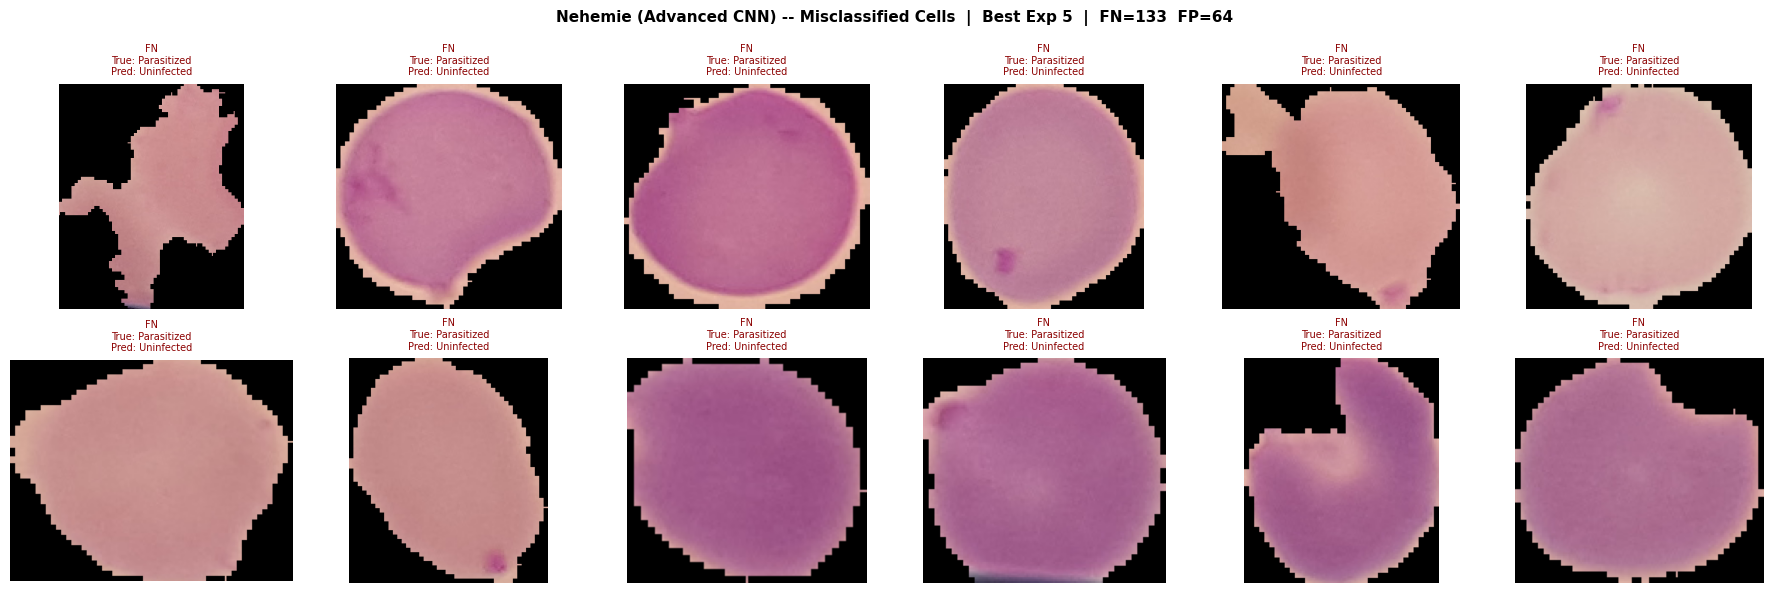

In [ ]:
# Error Analysis
tg_tmp, eg_tmp = make_generators()
all_n_models = [n1, n2, n3, n4, n5, n6, n7]
bm_n = all_n_models[best_n['id'] - 1]
eg_tmp.reset()
probs_n_err = bm_n.predict(eg_tmp, verbose=0).flatten()
yp_n_err    = (probs_n_err >= 0.5).astype(int)
yt_n_err    = eg_tmp.classes
wrong_n     = np.where(yp_n_err != yt_n_err)[0]
fn_n = [idx for idx in wrong_n if yt_n_err[idx]==0 and yp_n_err[idx]==1]
fp_n = [idx for idx in wrong_n if yt_n_err[idx]==1 and yp_n_err[idx]==0]
print(f'Nehemie (Advanced CNN) Best Exp {best_n["id"]}')
print(f'  Total misclassified : {len(wrong_n)}')
print(f'  False Negatives (missed parasites) : {len(fn_n)}')
print(f'  False Positives (false alarms)     : {len(fp_n)}')
cnames_n = list(eg_tmp.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f'Nehemie (Advanced CNN) -- Misclassified Cells  |  Best Exp {best_n["id"]}  |  FN={len(fn_n)}  FP={len(fp_n)}',
             fontsize=11, fontweight='bold')
for i_e, idx in enumerate(wrong_n[:12]):
    row, col = divmod(i_e, 6)
    axes[row, col].imshow(pyplot.imread(eg_tmp.filepaths[idx]))
    axes[row, col].axis('off')
    err_type = 'FN' if (yt_n_err[idx]==0 and yp_n_err[idx]==1) else 'FP'
    axes[row, col].set_title(
        f'{err_type}\nTrue: {cnames_n[yt_n_err[idx]]}\nPred: {cnames_n[yp_n_err[idx]]}',
        fontsize=7, color='darkred')
pyplot.tight_layout()
pyplot.savefig('Nehemie_error_analysis.png', dpi=150, bbox_inches='tight')
pyplot.show()

#### Looking at What Each Run Gave Me

**Going through the experiments**

Experiment 1 already had BatchNormalization and Dropout from the start so the training and validation curves were much closer together right away compared to the baseline which confirmed that BN and dropout working together really do reduce overfitting in a visible way.

**Experiment 2 (4 blocks):** Adding a fourth block gave the model more capacity to learn richer features but it also increased the number of parameters which means there is more room for the training accuracy to pull ahead of validation accuracy as a sign of overfitting from the extra depth.

**Experiment 3 (no BatchNormalization):** Without BN the training was noisier and the loss curve moved around more across epochs which showed that BatchNormalization is doing real work keeping the training stable and not just sitting there unused.

**Experiment 4 (L2 regularization):** L2 adds a penalty on large weights in the conv layers and when combined with dropout both the weights and the activations are being regularized at the same time so if both accuracies dropped it would mean the combined regularization went too far and underfitting had started.

**Experiment 5 (GlobalAveragePooling):** After the third MaxPool the feature map is 16 by 16 so Flatten turns that into about 32,000 values going into the Dense head while GlobalAveragePooling reduces it to just 128 and if Experiment 5 scores better than Experiment 1 that means the Flatten head was where most of the overfitting was coming from.

**Experiment 6 (combined techniques):** Having GAP, BN, Dropout and augmentation all active together gives the model the most regularization possible and this was expected to give the best validation performance out of all the runs.

**Experiment 7 (SGD with Nesterov):** SGD sometimes generalizes better than Adam on image tasks but it usually needs more epochs to get there and within the 20 epoch limit this model may not have finished converging fully.

**Error Analysis:**

The images above show the cells the best model got wrong. False Negatives are parasitized cells the model called uninfected and these are the most dangerous mistakes in a medical setting because a sick patient would not get treatment. False Positives are healthy cells flagged as parasitized which leads to unnecessary treatment but is less dangerous. Looking at these images helps understand whether the errors come from image quality problems or from cells that genuinely look very similar between the two classes.